# 🏠 [3주차] Ames 집값 EDA & 전처리 의사결정 파이프라인

---

### 과제 설명
미국 아이오와주 에임스市에서 거래된 주택 **1,460건**의 데이터를 가지고, 강의에서 배운 EDA·기술통계를 **직접 적용**하는 작은 프로젝트다. 목표는 "모델을 만드는 것"이 아니라, 데이터를 관찰하고 **"그래서 어떻게 전처리할 것인가"를 스스로 결정**하는 것이다.

### 어떻게 진행되나? (모든 파트가 같은 3단계 반복)
> **① 실습** → **② 해석**  → **③ 의사결정**

`______` 빈칸 또는 `# TODO`로 남겨둔 *빈칸 몇 개와, 그보다 훨씬 중요한 "✍️ 서술형" 답** 를 채워주세요.

### ⚠️ 제출 규칙
1. 모든 `______` 빈칸과 `# TODO`를 채운다.
2. **"✍️ 서술형"** 답은 반드시 **본인 데이터의 실제 수치를 인용**해 작성한다. (예: "SalePrice 왜도가 1.88이므로…")
3. **맨 마지막 셀**에 생성형 AI(GPT/Claude) 사용 내역을 붙여넣는다. (안 썼으면 "사용 안 함")

---
## 0. 환경 설정 & 데이터 로드

아래 셀들을 순서대로 실행한다. 라이브러리를 불러오고, 인터넷에서 데이터를 바로 읽어온다. (별도 파일 업로드 불필요)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 100)
print("라이브러리 준비 완료 ✅")

라이브러리 준비 완료 ✅


In [ ]:
# 데이터 불러오기: Ames Housing (1460행 × 81열)
URL = "https://raw.githubusercontent.com/hjhuney/Data/master/AmesHousing/train.csv"
df = pd.read_csv(URL)

print("데이터 크기 (행, 열):", df.shape)
df.head()

데이터 크기 (행, 열): (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


> **데이터 설명**: 한 행(row)이 주택 1채의 거래 기록이다. 예측 대상(타깃)은 `SalePrice`(판매가, 달러)이고, 나머지 79개 컬럼이 그 집의 특징(면적·품질·동네·차고 등)이다.

---
# Part 1. 데이터 타입의 정렬 — dtype vs 실제 의미

> ① 실습: `info()`·`describe()`로 전체를 보고, `MSSubClass`의 기술통계를 확인
> ② 해석: 컴퓨터가 '숫자'로 읽은 변수가 정말 사칙연산이 되는 변수인지 비판적으로 검토
> ③ 의사결정: 인코딩 전략을 결정

In [ ]:
# ① 전체 형태 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# 수치형 변수들의 요약 통계
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
# MSSubClass(주택 유형 코드)는 숫자로 저장돼 있다. 직접 확인해보자.

# TODO: dtype, 평균, 고유값을 출력하라
print("MSSubClass dtype :", df['MSSubClass'].dtype)           # 저장 타입
print("MSSubClass 평균  :", round(df['MSSubClass'].mean(), 2))  # 평균 계산
print("MSSubClass 고유값:", sorted(df['MSSubClass'].unique()))    # 고유값 목록
# 출력 결과를 보고 이 변수의 평균값이 의미 있는 숫자인지 생각해보자

MSSubClass dtype : int64
MSSubClass 평균  : 56.9
MSSubClass 고유값: [np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(120), np.int64(160), np.int64(180), np.int64(190)]


**✍️ 서술형 Part 1**

**Q1.** `MSSubClass`의 평균값(위 출력)이 통계적으로 무의미한 이유를, 변수의 척도(명목/순서/등간/비율) 개념과 연결해 설명하세요. 그리고 모델이 이 변수를 크기가 있는 숫자로 오해하지 않도록 **어떤 인코딩**을 적용할지 결정하세요.
→ **답:** ______

**Q2.** 두 범주형 변수 `ExterQual`(외관 품질: Ex>Gd>TA>Fa>Po, 순서 있음)과 `Neighborhood`(동네 이름, 순서 없음)를 숫자로 바꾸려 합니다. 각각 **Ordinal 인코딩**과 **One-Hot 인코딩** 중 무엇을 써야 하며 그 이유는 무엇인가요? (힌트: 순서 정보가 있는가?)
→ **답:** ______

**A1.** MSSubclass는 숫자로 저장되어 있지만 실제로는 주택 유형을 구분하는 명목형 변수이다. 20,30,60 등의 값은 주택의 종류를 나타내는 코드일 뿐, 60이 20보다 3배 크거나 더 우수하다는 의미가 없다. 따라서 이 변수의 평균값이 56.9는 통계적으로 의미있는 수치라고 보기 어렵다. 모델이 코드의 크기나 간격을 실제 수치 관계로 오해하지 않도록 MSSbclass를 문자열이나 범주형 변수로 변환하고 One-Hot 인코딩을 적용하는 것이 적절하다.

**A2.** ExterQual은 품질의 높고 낮음에 정확한 순서가 있는 순서형 범주이므로 각 범주에 순서를 반영한 값을 부여하는 Ordinal 인코딩을 적용해야한다.(예를 들어 Po=1, Fa=2, TA=3, Gd=4, Ex=5 이런식으로) 반면 Neighborhood는 동네 이름을 나타내며 범주 간의 순서가 없는 명목형 변수이므로 One-Hot 인코딩을 적용해야 한다. 임의로 숫자를 부여하면 모델이 숫자의 크기에 따른 순서가 있다고 잘못 해석할 여지가 있기 때문이다.

---
# Part 2. Target 변수의 분포와 변환 전략

> ① 실습: `SalePrice`의 히스토그램·왜도·첨도, 그리고 `LotArea`의 평균 vs 중앙값
> ② 해석: 꼬리가 어디로 치우쳤는지, 평균-중앙값 격차가 무엇을 뜻하는지 파악
> ③ 의사결정: 로그 변환 필요 여부, 대표값 선택

평균  : 180,921
중앙값: 163,000
왜도  : 1.88
첨도  : 6.54


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

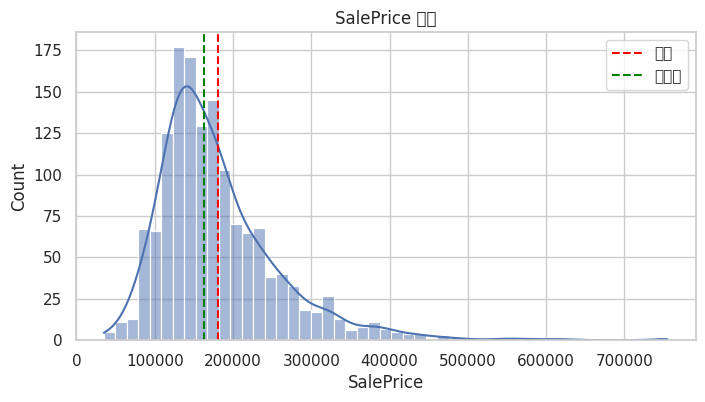

In [ ]:
# ① SalePrice 분포 진단
sp = df['SalePrice']

# TODO: 왜도(skewness)와 첨도(kurtosis)를 구하라  (힌트: 시리즈의 .skew() , .kurt())
skew_ = sp.skew()
kurt_ = sp.kurt()

print(f"평균  : {sp.mean():,.0f}")
print(f"중앙값: {sp.median():,.0f}")
print(f"왜도  : {skew_:.2f}")
print(f"첨도  : {kurt_:.2f}")

plt.figure(figsize=(8,4))
sns.histplot(sp, kde=True)
plt.axvline(sp.mean(),   color='red',   ls='--', label='평균')
plt.axvline(sp.median(), color='green', ls='--', label='중앙값')
plt.title('SalePrice 분포'); plt.legend(); plt.show()

In [ ]:
# LotArea(부지 면적)의 평균 vs 중앙값 비교
print(f"LotArea 평균  : {df['LotArea'].mean():,.0f}")
print(f"LotArea 중앙값: {df['LotArea'].median():,.0f}")
print(f"LotArea 최댓값: {df['LotArea'].max():,.0f}  <- 극단값 확인")

LotArea 평균  : 10,517
LotArea 중앙값: 9,478
LotArea 최댓값: 215,245  <- 극단값 확인


**✍️ 서술형 Part 2**

**Q1.** `SalePrice`의 왜도 부호와 분포 꼬리 방향(좌왜/우왜)을 쓰고, 이 분포를 선형 모델에 넣을 때 어떤 변환(예: 로그 변환)이 필요한지 결정하세요. 변환한다면 왜도 수치가 어떻게 변할지도 예측해보세요.
→ **답:** ______

**Q2.** `LotArea`의 평균과 중앙값 중, 현재 데이터의 '대표값'으로 더 적절한 것은? 극단적 이상치가 통계량에 미치는 영향을 근거로 방어하세요.
→ **답:** ______

**A1.** SalePrice의 왜도는 1.88로 양수이고 분포는 우측왜도를 가진다. 이러한 분포를 선형 모델에 그대로 적용하면 극다적으로 큰 값의 영향이 커지고 잔차의 정규성이나 등분산성 가정이 약해질 수 있다. 따라서 로그변환을 적용하는 것이 적절하다. 로그 변환 후에는 큰 가격 값들이 상대적으로 더 많이 압축되므로 오른쪽 꼬리가 약해지고 왜도는 좀 더 0에 가까운 값으로 감소할 것이다.

**A2.** LotArea의 대표값으로는 중앙값이 더 적절하다. 최대값이 215,245로 일반적인 값들보다 매우 큰 극단값이 존재하고 이런 이상치는 평균을 크게 끌어올린다. 반면 중앙값은 데이터를 크기순으로 정렬하여 구하는 값으로 극단값의 영향을 거의 받지 않는다. 따라서 큰 이상치가 포함된 현재 분포에서는 평균보다 중앙값이 더 안정적으로 결과를 나타낸다.

/tmp/ipykernel_16792/2563761168.py:7: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16792/2563761168.py:7: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16792/2563761168.py:7: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16792/2563761168.py:7: UserWarning: Glyph 50780 (\N{HANGUL SYLLABLE WAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16792/2563761168.py:7: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16792/2563761168.py:7: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtool

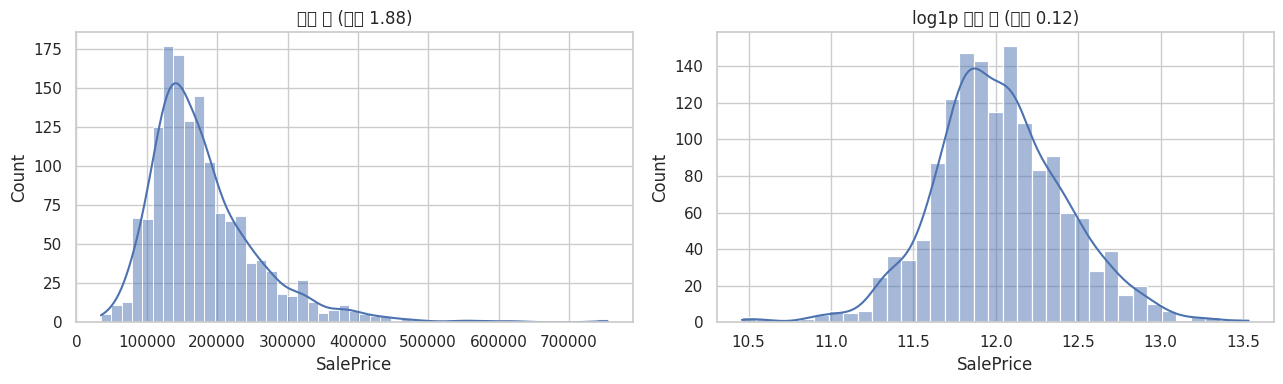

변환 후 왜도가 0에 가까워졌는가? 0.121


In [ ]:
# ③ 로그 변환을 직접 적용해 예측이 맞았는지 확인
sp_log = np.log1p(sp)   # log1p = log(1+x), 0이 있어도 안전

fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(sp,     kde=True, ax=ax[0]); ax[0].set_title(f'변환 전 (왜도 {sp.skew():.2f})')
sns.histplot(sp_log, kde=True, ax=ax[1]); ax[1].set_title(f'log1p 변환 후 (왜도 {sp_log.skew():.2f})')
plt.tight_layout(); plt.show()
print("변환 후 왜도가 0에 가까워졌는가?", round(sp_log.skew(), 3))

---
# Part 3. 결측치 비율에 따른 입체적 대체 전략 🔥

> ① 실습: 결측 컬럼과 비율을 내림차순 테이블로
> ② 해석: 높은 결측(FireplaceQu)·애매한 결측(LotFrontage)·0 밀집(MasVnrArea)의 맥락 유추
> ③ 의사결정: 컬럼마다 다른 처방을 설계

이 파트가 이번 과제의 **변별력 구간**입니다. "결측이면 무조건 채운다/버린다"가 아니라, 결측이 왜 생겼는지에 따라 처방이 달라집니다.

In [ ]:
# ① 결측 비율(%) 내림차순
miss = (df.isnull().mean()*100).sort_values(ascending=False)
miss = miss[miss > 0].round(1)
print("결측이 있는 컬럼 수:", len(miss))
miss.head(20)

결측이 있는 컬럼 수: 19


,0
PoolQC,99.5
MiscFeature,96.3
Alley,93.8
Fence,80.8
MasVnrType,59.7
FireplaceQu,47.3
LotFrontage,17.7
GarageQual,5.5
GarageFinish,5.5
GarageType,5.5


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

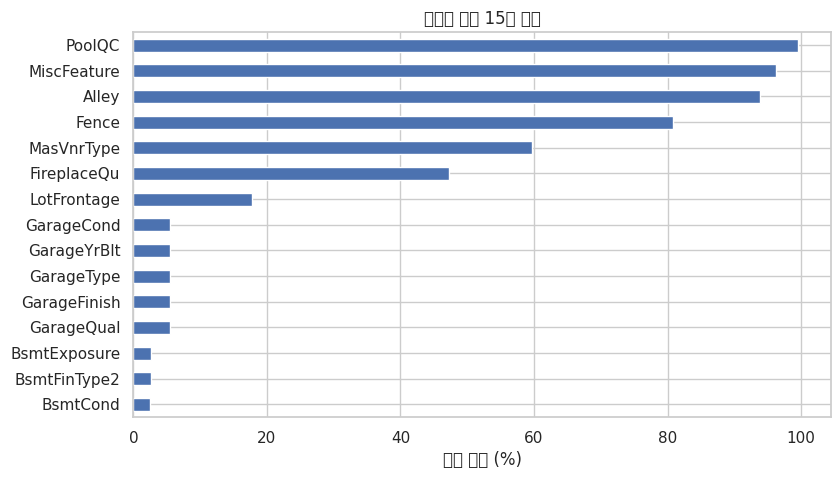

In [ ]:
# 결측 비율 상위 시각화
plt.figure(figsize=(9,5))
miss.head(15).sort_values().plot(kind='barh')
plt.xlabel('결측 비율 (%)'); plt.title('결측치 상위 15개 컬럼'); plt.show()

In [ ]:
# ② 세 변수의 맥락을 조사해보자
# (a) FireplaceQu(벽난로 품질)가 결측인 집의 Fireplaces(벽난로 개수)는?
print("[FireplaceQu 결측 행의 벽난로 개수]")
print(df.loc[df['FireplaceQu'].isnull(), 'Fireplaces'].value_counts(), "\n")

# (b) MasVnrArea(조적 베니어 면적)의 값 분포 — 0이 얼마나 몰려있나?
# 힌트: 0인지 아닌지를 True/False(=1/0)로 변환 → 합산하면 0의 개수, 평균내면 0의 비율
print("[MasVnrArea] 결측 개수:", df['MasVnrArea'].isnull().sum(),
      "| 값이 0인 비율: %.1f%%" % ((df['MasVnrArea'] == 0).mean() * 100))

# (c) LotFrontage 결측을 전체 중앙값 하나로 채우면 동네마다 도로 폭이 다른데도
# 모든 집에 같은 값이 들어간다. 동네별로 중앙값이 실제로 다른지 확인해보자. >> 도구 : groupby
# TODO: 동네(Neighborhood)를 기준으로 묶어 LotFrontage의 중앙값을 구하라
print("[동네별 LotFrontage 중앙값 (일부)]")
print(df.groupby('Neighborhood')['LotFrontage'].median().dropna().head(6))

[FireplaceQu 결측 행의 벽난로 개수]
Fireplaces
0    690
Name: count, dtype: int64 

[MasVnrArea] 결측 개수: 8 | 값이 0인 비율: 59.0%
[동네별 LotFrontage 중앙값 (일부)]
Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Name: LotFrontage, dtype: float64


**✍️ 서술형 Part 3**

**Q1 [구조적 결측].** `FireplaceQu`는 결측률이 약 47%지만, 위 (a)에서 보듯 결측 행은 전부 벽난로 개수가 0이다. 즉 결측이 아니라 **'벽난로 없음'이라는 정보**다. 이 컬럼을 그냥 '열 삭제'하면 왜 위험한가요? 데이터를 보존하는 본인만의 처리법(예: `'None'` 범주 부여)을 제시하세요.
→ **답:** ______

**Q2 [0 밀집 분포].** `MasVnrArea`는 값의 약 59%가 0(=베니어 없음)이다. 이 소수의 결측(8건)을 **'0을 포함한 전체 평균값'**으로 채우면 어떤 왜곡이 생기는가? 더 안전한 대안은?
→ **답:** ______

**A1.** FirepalceQu의 결측치는 단순히 값이 누락된 것이 아니라 대부분 벽난로가 없는 집을 의미하는 구조적 결측이다. 실제로 FirepalceQu가 결측인 690개 행의 FirepalceQu의 값이 모두 0이므로, 이 열을 삭제하면 "벽난로 없음"이라는 정보를 잃게된다. 따라서 결측값을 일반 품질 범주와 구분되게 None과 같은 별도 범주로 채우는 것이 적절하다. ex) df['FirepalceQu'] = df['FirepalceQu'].fillna('None')

**A2.** MasVnrArea는 전체 값의 약 59%가 0이므로 0이 많이 포함된 치우친 분포이다. 이 상태에서 결측값 8개를 0까지 포함한 전체 평균값으로 채우면 많은 0의 영향으로 평균이 낮아서 실제로 베니어 면적이 존재하는 집의 결측값을 과소 추정할 수 있다. 또한 결측이 단순 누락인지 실제 베니어 없음인지 구분하지 못하고 잘못된 면적을 부여하게 될 수도 있다.
더 안전한 방법은 MasVnrType을 함께 확인해서 베니어가 없는 경우면 0으로 채우고, 베니어가 존재하지만 면적이 결측인거라면 0이 아닌 값들의 중앙값으로 채우거나 MasVnrType별 중앙값으로 채우는게 좀 더 적절한 대안이다. 중앙값을 쓰면 큰 면적의 이상치 영향도 덜 받게 된다.

---
# Part 4. 의미 있는 이상치와 파생 변수의 부작용

> ① 실습: `GrLivArea` vs `SalePrice` 산점도에서 이상 패턴 포착, `Total_Area` 파생 변수 생성
> ② 해석: 포착된 점이 수집 오류(Noise)인지 실제 거래(의미 있는 이상치)인지 추론
> ③ 의사결정: 제거할지 유지할지, 파생 변수의 부작용 대응

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


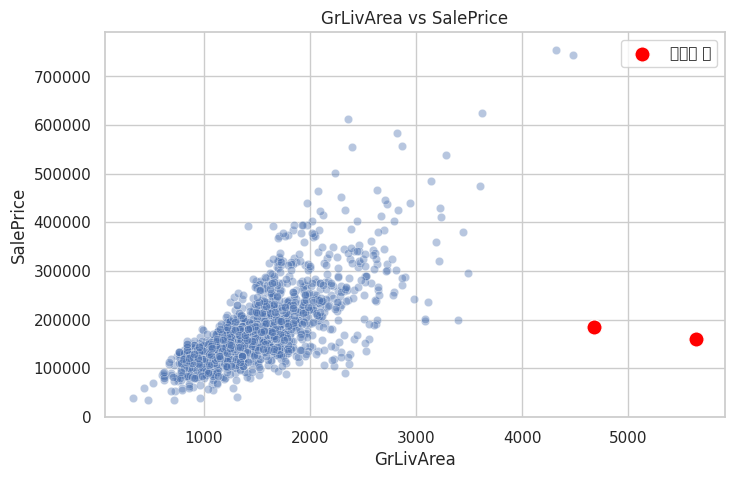

수상한 점 개수: 2
      GrLivArea  SalePrice  OverallQual SaleCondition
523        4676     184750           10       Partial
1298       5642     160000           10       Partial


In [ ]:
# ① 산점도로 이상 패턴 찾기
plt.figure(figsize=(8,5))
# TODO: 두 변수의 관계를 산점도로 그려라
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.4)

# 면적은 아주 큰데(>4000) 가격은 낮은(<200000) 수상한 점을 빨간색으로
weird = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)]
# TODO: 위에서 걸러낸 이상점을 빨간색으로 덧그려라
sns.scatterplot(data=weird, x='GrLivArea', y='SalePrice', color='red', s=120, label='수상한 점')
plt.title('GrLivArea vs SalePrice'); plt.legend(); plt.show()

print(f"수상한 점 개수: {len(weird)}")
print(weird[['GrLivArea','SalePrice','OverallQual','SaleCondition']])

In [ ]:
# ③ 여러 면적 변수를 더해 Total_Area 파생 변수 생성
df['Total_Area'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

# 새 변수와 기존 변수들의 상관을 확인
print(df[['Total_Area','1stFlrSF','2ndFlrSF','TotalBsmtSF','SalePrice']].corr()['SalePrice'].round(3))

Total_Area     0.782
1stFlrSF       0.606
2ndFlrSF       0.319
TotalBsmtSF    0.614
SalePrice      1.000
Name: SalePrice, dtype: float64


**✍️ 서술형 Part 4**

**Q1 [이상치 판단].** 빨간 점 2개는 `SaleCondition`이 `Partial`(미완공 상태 거래)이다. 이들을 **노이즈로 보고 완전히 제거**할 것인가, 아니면 **유지하되 이상치에 강건한 트리 계열 모델**을 쓸 것인가? 본인의 결정 논리를 서술하라.
→ **답:** ______

**Q2 [다중공선성].** `Total_Area`는 `1stFlrSF + 2ndFlrSF + TotalBsmtSF`의 합이라, 이 셋과 거의 완벽하게 겹친다(위 상관 확인). 파생 변수와 원본 3개를 **모두** 모델에 넣으면 왜 문제가 되는가? (힌트: 서로 강하게 상관된 변수를 중복 투입 = 다중공선성) 원본을 유지할지 삭제할지 결정하라.
→ **답:** ______

**A1.** 빨간 점 2개는 GrLivArea가 4,000 이상으로 매우 큰데도 SalePrice가 20만 달러 미만으로 일반적인 면적-가격 관계에서 크게 벗어난다. 특수 거래 사례지만 일반적인 완공 주택의 가격을 예측하는 모델에서는 대표성이 낮고 학습패턴을 왜곡할 수 있다. 특히나 표본이 2개밖에 되지 않아서 트리 계열 모델이 이 사례를 설명하기 위해 불필요한 분할을 만들 가능성도 있다. 따라서 일반적인 주택 가격 예측을 목표로 한다면 이상치로 판단하고 제거하는 것이 적절할 것 같다.

**A2.** 네 변수를 모두 모델에 넣으면 동일한 면적 정보가 중복된다. 특히 선형회귀에서는 변수 사이에 거의 완전한 선형관계가 생겨 다중공선성이 발생하고 회귀계수가 불안정해지거나 각 변수의 개별 효과를 해석하기 어려워질 수 있다. 따라서 SalePrice와의 상관계수가 0.782로 원본 변수보다 높은 Total_Area를 유지하고 원본 3개 변수는 삭제하는 것이 적절하다. 혹여나 층별 면적 자체의 차이가 중요한 경우라면 Total_Area를 제외하고 원본 변수를 유지하는 방식이 좀 더 효과적일 수 있다.

---
# Part 5. 다변량 관계의 함정과 Target Leakage

> ① 실습: 수치형 상관 히트맵 + 범주형은 Boxplot으로
> ② 해석: 히트맵에 범주형(동네 등)의 영향력이 누락됨을 인지
> ③ 의사결정: 분석의 맹점, Target Leakage 필터링

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

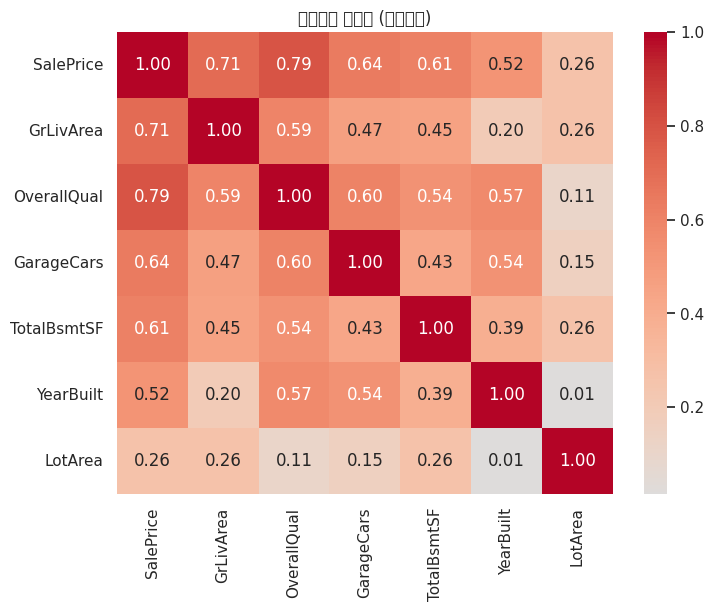

In [ ]:
# ① 수치형 상관 히트맵
key = ['SalePrice','GrLivArea','OverallQual','GarageCars','TotalBsmtSF','YearBuilt','LotArea']
plt.figure(figsize=(8,6))
# TODO: 상관계수 행렬을 구하고 히트맵으로 그려라
sns.heatmap(df[key].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('상관계수 히트맵 (수치형만)'); plt.show()

/tmp/ipykernel_16792/2376747616.py:6: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=90); plt.title('동네별 SalePrice 분포'); plt.tight_layout(); plt.show()
/tmp/ipykernel_16792/2376747616.py:6: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=90); plt.title('동네별 SalePrice 분포'); plt.tight_layout(); plt.show()
/tmp/ipykernel_16792/2376747616.py:6: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=90); plt.title('동네별 SalePrice 분포'); plt.tight_layout(); plt.show()
/tmp/ipykernel_16792/2376747616.py:6: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=90); plt.title('동네별 SalePrice 분포'); plt.tight_layout(); plt.show()
/tmp/ipykernel_16792/2376747616.py:6: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=90); p

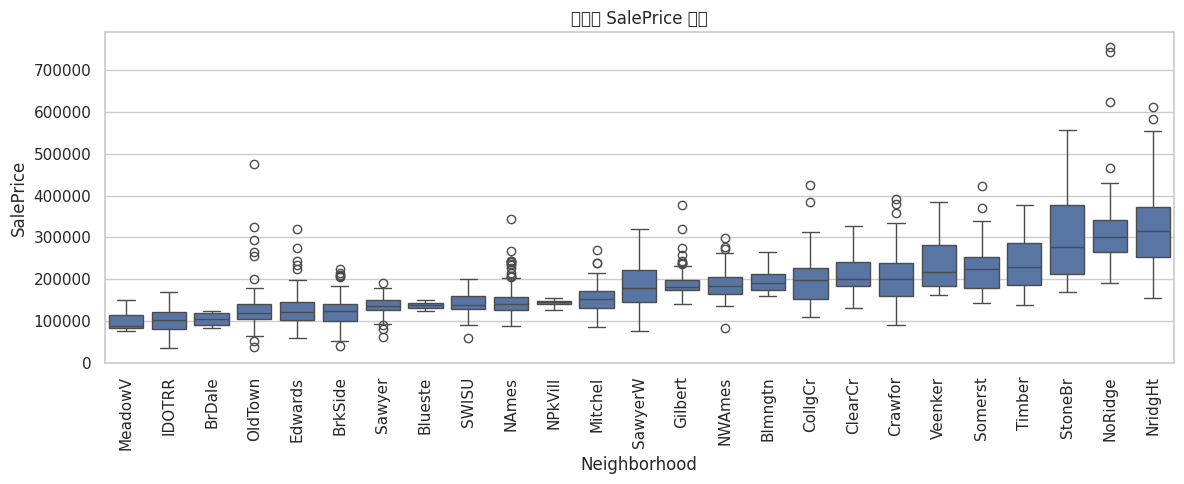

가장 싼 동네 중앙값 88,000 vs 가장 비싼 동네 315,000  (3.6배)


In [ ]:
# 히트맵엔 없는 범주형 Neighborhood(동네)의 영향력을 Boxplot으로
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
plt.figure(figsize=(12,5))
# TODO: 동네별 SalePrice 분포를 박스플롯으로 그려라
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order)
plt.xticks(rotation=90); plt.title('동네별 SalePrice 분포'); plt.tight_layout(); plt.show()

nb = df.groupby('Neighborhood')['SalePrice'].median()
print(f"가장 싼 동네 중앙값 {nb.min():,.0f} vs 가장 비싼 동네 {nb.max():,.0f}  ({nb.max()/nb.min():.1f}배)")

**✍️ 서술형 Part 5**

**Q1 [분석의 맹점].** 위 수치형 히트맵만 보고 "집값에 영향을 주는 건 이 수치형 변수들뿐"이라고 결론 내리면 무엇을 놓치는가? Boxplot에서 드러난 `Neighborhood`의 영향력을 근거로, 강의에서 배운 **히트맵의 3가지 맹점 중 어느 것**에 해당하는지 짚어라.
→ **답:** ______

**Q2 [Target Leakage].** 데이터에 '판매 직전 납부한 취등록세액' 변수가 있고 `SalePrice`와 상관이 0.99라고 하자. 취등록세는 보통 판매가에 비례해 매겨진다. 이 변수를 피처에서 **제외해야 하는 이유**를 Target Leakage 관점에서 설명하라. (힌트: 집을 팔기 *전에* 알 수 있는 값인가?)
→ **답:** ______

**A1.** 수치형 상관 히트맵은 Neighborhood 같은 범주형 변수를 포함하지 않기 때문에 동네에 따른 집값 차이를 확인할 수 없다. 그러나 박스플롯에서는 동네별 SalePrice 중앙값이 88,000에서 315,000까지 약 3.5배가 차이나므로 Neighborhood가 집값에 큰 영향을 주는 변수임을 알 수 있다. 따라서 이는 히트맵의 맹점 중 범주형 변수의 부재에 해당한다.

**A2.** '판매 직전 납부한 취등록세액'은 판매가가 결정된 후에 계산되는 값이기 때문에 집을 팔기 전에는 알 수 없는 정보이다. 따라서 이를 학습 피처를 사용하면 모델이 예측시점에 알 수 없는 정보를 알게 되는거니까 Target Leakage가 발생한다. SalePrice와 상관계수가 0.99로 매우 높더라도 실제 예측 환경에서는 사용할 수 없으므로 반드시 제외해야 한다.

---
# Part 6. 데이터 누수 없는 파이프라인 (심화·선택)

> ① 실습: Train/Test 분할 후, 대체·스케일링 코드의 TODO를 채워 올바르게 작동시키기
> ② 해석: "Train 통계로 Test를 채운다"는 원리와 정보 유출의 차이
> ③ 의사결정: 분할을 '가장 먼저' 해야 하는 원칙 선언

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 간단히 수치형 변수 몇 개만 사용
feats = ['GrLivArea','OverallQual','TotalBsmtSF','GarageCars','LotFrontage']
X = df[feats].copy()
y = np.log1p(df['SalePrice'])

# 1) 가장 먼저 Train/Test 분할  (random_state는 본인 학번 뒤 4자리로!)
# TODO: 아래 ______ 에 본인 학번 앞 4자리 (예: 2021학번이면 2021)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

# 2) 결측 대체: Train 에서 fit, Test 에는 transform 만
imp = SimpleImputer(strategy='median')
X_train_imp = imp.fit_transform(X_train)          # fit_transform: Train 통계를 '학습'하며 변환
# TODO: Test 는 새로 fit 하지 말고, Train 이 학습한 값으로 transform 만 하라
X_test_imp  = imp.transform(X_test)

# 3) 스케일링도 동일 원칙 (Train 에서만 fit)
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train_imp)
# TODO: Test 스케일링 (transform 만)
X_test_sc  = sc.transform(X_test_imp)

print("완료 — Train:", X_train_sc.shape, "/ Test:", X_test_sc.shape)
print("Train 중앙값으로 채운 LotFrontage 대체값:", round(imp.statistics_[feats.index('LotFrontage')], 1))

완료 — Train: (1168, 5) / Test: (292, 5)
Train 중앙값으로 채운 LotFrontage 대체값: 70.0


**✍️ 서술형 Part 6**

**Q1.** Test 데이터에 `fit`(또는 `fit_transform`)을 하면 안 되는 이유를, "Test는 미래에 들어올 미지의 데이터"라는 관점에서 설명하세요. Test의 통계(평균·중앙값)를 미리 들여다보면 무엇이 새어나갈까요?
→ **답:** ______

**Q2.** 결측 대체·스케일링 같은 전처리보다 **Train/Test 분할을 반드시 먼저** 해야 하는 본인의 행동 원칙을, 데이터 누수 방지 측면에서 말해주세요.
→ **답:** ______

**A1.** fit은 평균, 중앙값, 표준편차 같은 통계량을 학습하는 과정인데, 이때 Test의 통계량까지 사용하면 원래는 알 수 없어야 할 미래 데이터의 정보를 미리 본 셈이 된다. 그러면 전처리 단계에서 Test정보가 Train에 간접적으로 반영되어 데이터 누수가 발생하고 모델 성능이 실제보다 좋게 보여질 수 있다. 따라서 Train에서만 fit하고 Test에서는 Train에서 학습한 값으로 trsnsform만 적용해야한다. 

**A2.** 전체 데이터를 먼저 전처리하면 테스트 데이터의 중앙값, 평균, 표준편차 등이 전처리 기준 계산에 포함되어 학습과정으로 흘러들어가게 되어 데이터 누수가 발생한다. 따라서 먼저 train/test를 분할한 후 train에서만 전처리 기준을 학습하고 test에서는 동일한 기준을 적용해야한다.

---
# 📌 [필수] 생성형 AI 활용 방법

이 과제를 풀며 GPT/Claude 등을 **어디에, 어떻게** 썼는지 기록한다. (안 썼으면 "사용 안 함")


**답변**

- **활용한 부분:** 서술형 내용 검토/첨삭
- **대화 내역:**

---
# 🪞 회고
- 가장 어려웠던 부분과 이유:

A. <미완공 상태 거래> 이상치 값을 제거할지 유지할지 선택하는 과정이 어려웠음. 특수성을 가진 사례이기 때문에 완전히 노이즈로 봤을 때 최종 모델 예측에서 놓치는 부분이 생길수도 있고, 그러나 유지하기엔 이상치의 수가 2개로 적기도 하고 기본 예측에 오히려 더 부정적인 영향을 미칠 수 있기 때문에 이부분을 비교적 오래 고민함.

- 강의 땐 이해했다고 생각했지만 직접 해보며 새로 깨달은 점:

A. 개념을 이해하는 것은 항상 스스로의 합리화도 어느정도 포함되어 있다고 생각하고.. 실습을 하며 항상 이것을 새로 깨닫는듯 함. 적용이라는 것은 하나의 개념 이해를 넘어서 전체 흐름을 보는 시야가 필요하기 때문에 너무 작은 것에 몰입되기 보다는 먼저 큰 틀을 잘 설계해야 겠다는 생각을 함.
